In [1]:
%pip install numpy
%pip install scipy
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import numpy.linalg as linalg
from scipy.integrate import ode
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation

In [ ]:
def solve_wave(k: float, spring_count: int, v0: float, A: float, omega: float, phi: float,
               max_t: float, dt: float = 0.01
                  ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    def derivatives(t: float, state: np.ndarray) -> np.ndarray:
        x = state[:len(state) // 2]
        v = state[len(state) // 2:]

        F_link = k * (x[1:] - x[:-1])
        a = np.concat([[0], F_link[1:] - F_link[:-1], [0]])
        a[1] += A * np.cos(omega * t + phi)

        derivatives = np.concat([v, a])
        return derivatives

    integrator = ode(derivatives)
    integrator.set_integrator('vode', method='bdf', order=5, 
                         nsteps=3000, rtol=1e-6, atol=1e-8)

    initial_v = np.zeros(spring_count)
    initial_v[1] = v0

    initial_state = np.concat([np.zeros(spring_count), initial_v])
    integrator.set_initial_value(initial_state, 0)

    t_values = []
    x_values = []
    v_values = []

    while integrator.successful() and integrator.t < max_t:
        state = integrator.integrate(integrator.t + dt)
        t_values.append(integrator.t)
        x_values.append(state[:len(state) // 2])
        v_values.append(state[len(state) // 2:])

    return (np.array(t_values), np.array(x_values), np.array(v_values))

In [11]:
def show_analysis(k: float, spring_count: int, v0: float, A: float, omega: float, phi: float, 
                  max_t: float, delta_t: float, delta_pos: float) -> FuncAnimation:
    t, x, v = solve_wave(k, spring_count, v0, A, omega, phi, max_t, delta_t)

    def wave_profile(t, x) -> tuple[np.ndarray, np.ndarray]:
        return np.arange(len(x[t])), x[t]

    fig, ax = plt.subplots(figsize=(12, 8))
    wave, = plt.plot(*wave_profile(0, x))
    plt.ylim(-0.5, 0.5)
    plt.grid(True)
    plt.show()

    def update(frame):
        wave.set_data(*wave_profile(frame, x))
        return wave,

    anim = FuncAnimation(fig, update, len(x), interval=50)

    potential_energy = np.sum(k * (x[:, 1:] - x[:, :-1]) ** 2 / 2, axis=1)
    kinetic_energy = np.sum(v**2 / 2, axis=1)

    plt.figure(figsize=(12, 8))
    plt.plot(t, potential_energy, label="Потенциальная энергия")
    plt.plot(t, kinetic_energy, label="Кинетическая энергия")
    plt.plot(t, potential_energy + kinetic_energy, label="Полная энергия")
    plt.ylim(bottom=0)

    plt.legend()
    plt.grid(True)
    plt.show()

    d2x_dt2 = (x[2:, :] + x[:-2, :] - 2 * x[1:-1, :])[:, 1:-1] / delta_t ** 2
    d2x_dpos2 = (x[:, 2:] + x[:, :-2] - 2 * x[:, 1:-1])[1:-1, :] / delta_pos ** 2

    c = np.sqrt(np.abs((d2x_dt2 / d2x_dpos2)))
    print(np.average(c[d2x_dpos2 > 1e-15]), np.sqrt(k))

    return anim

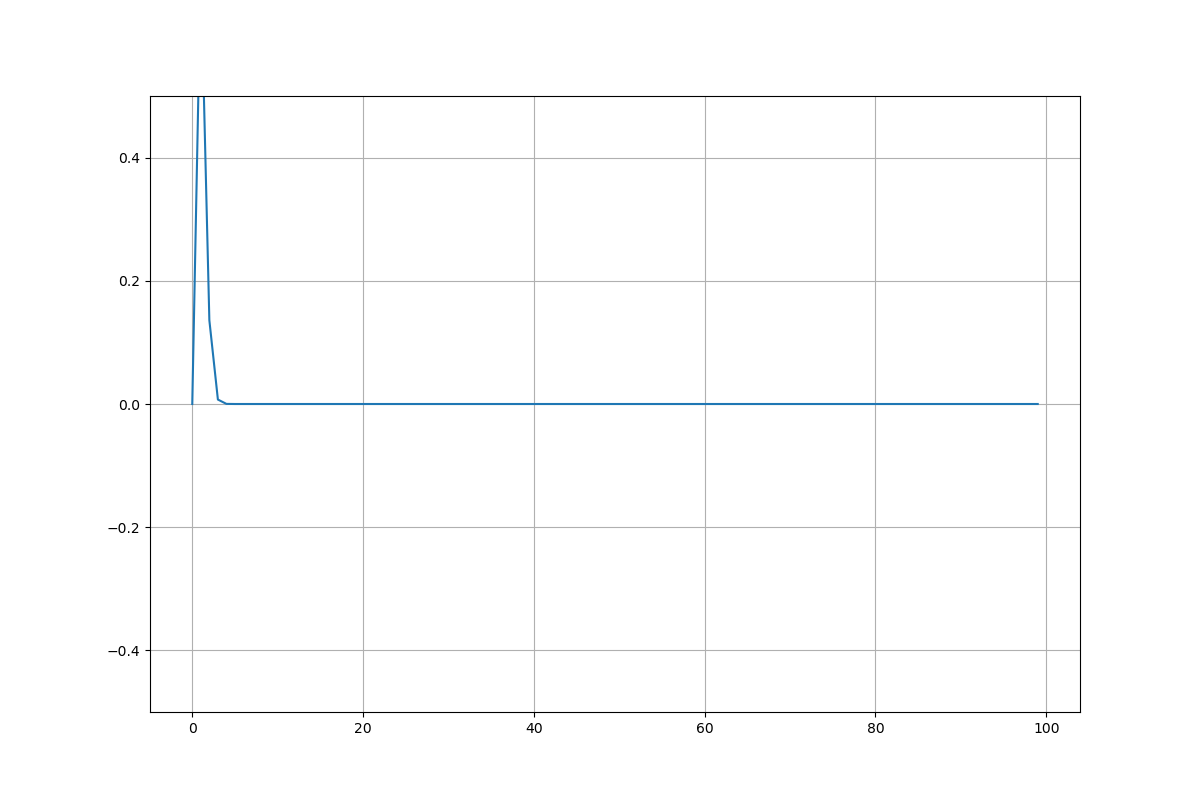

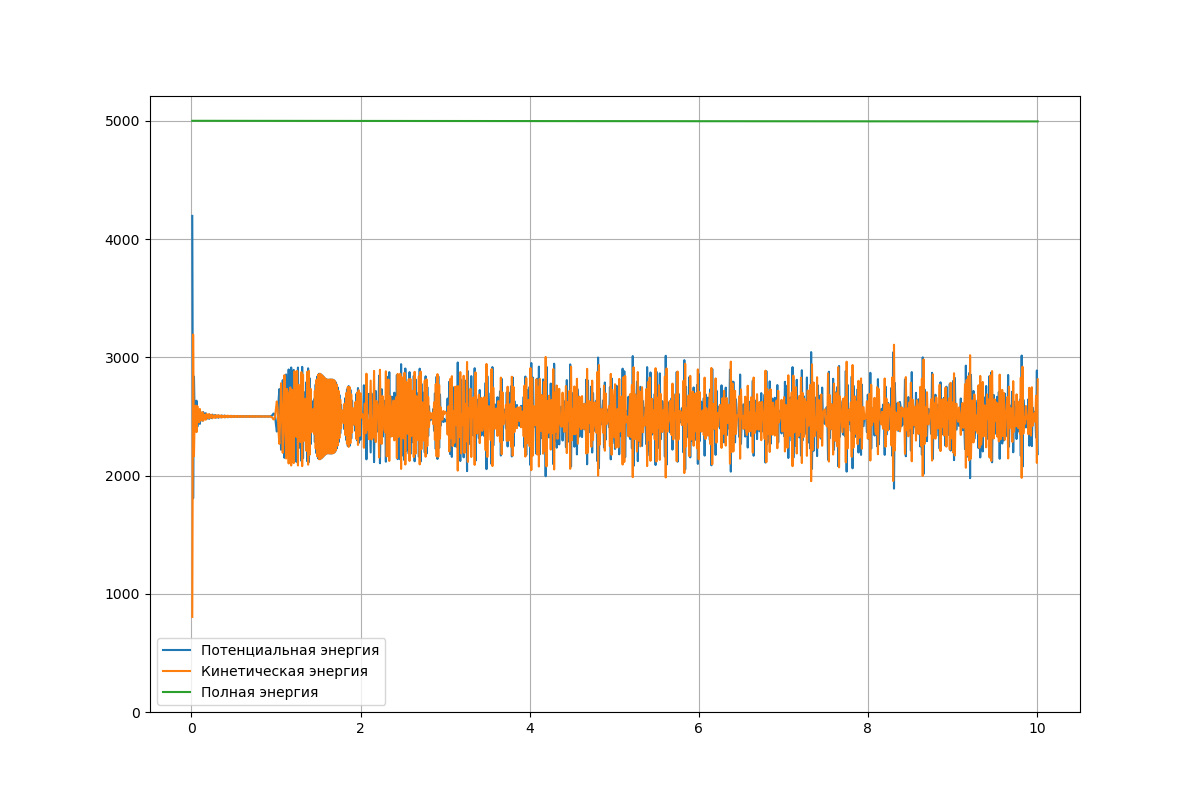

93.98646791920598 100.0


C:\Users\PJutch\AppData\Local\Temp\ipykernel_83848\168080776.py:36: RuntimeWarning: divide by zero encountered in divide
  c = np.sqrt(np.abs((d2x_dt2 / d2x_dpos2)))
C:\Users\PJutch\AppData\Local\Temp\ipykernel_83848\168080776.py:36: RuntimeWarning: invalid value encountered in divide
  c = np.sqrt(np.abs((d2x_dt2 / d2x_dpos2)))


In [12]:
%matplotlib widget

try:
    anim1.event_source.stop()
except Exception:
    pass

anim1 = show_analysis(10000, 100, 100, 0, 0, 0, 10, 0.01, 1)

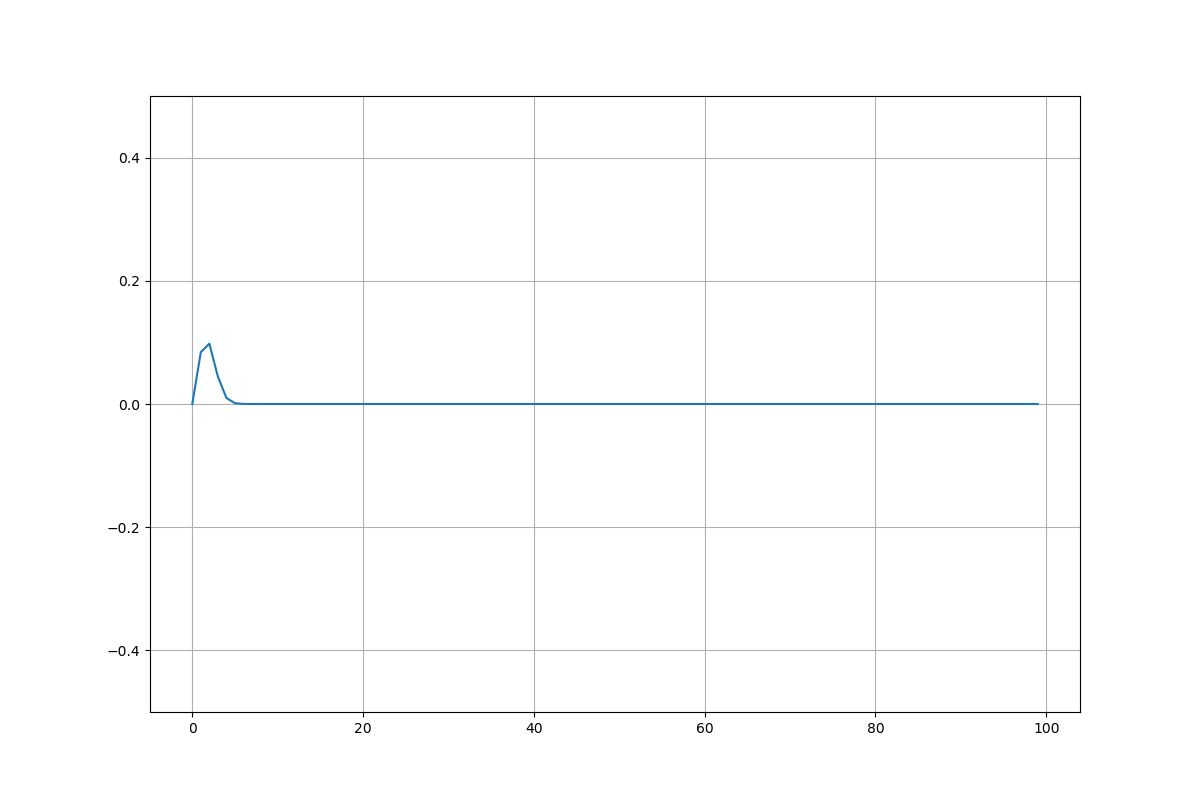

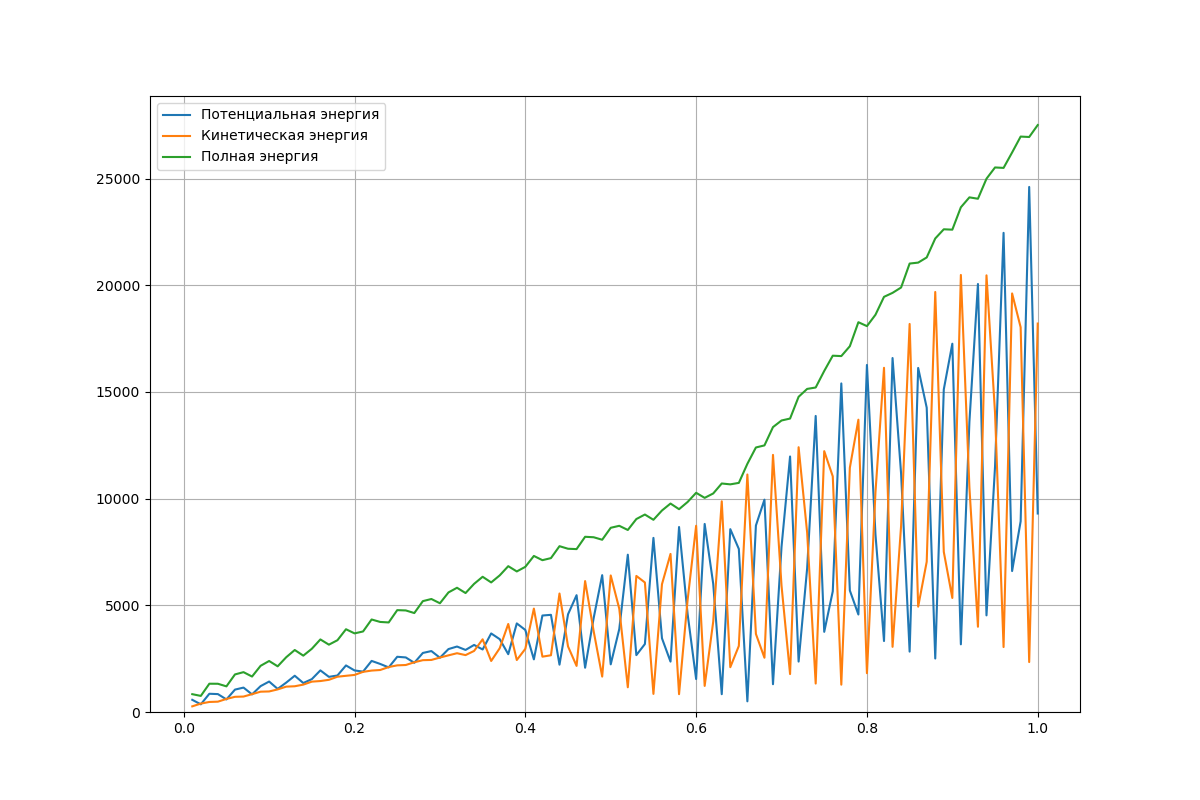

404.879563930446 316.22776601683796


C:\Users\PJutch\AppData\Local\Temp\ipykernel_83848\168080776.py:36: RuntimeWarning: divide by zero encountered in divide
  c = np.sqrt(np.abs((d2x_dt2 / d2x_dpos2)))


In [13]:
%matplotlib widget

try:
    anim2.event_source.stop()
except Exception:
    pass

anim2 = show_analysis(100000, 100, 0, 10000, 100, 0, 1, 0.01, 1)

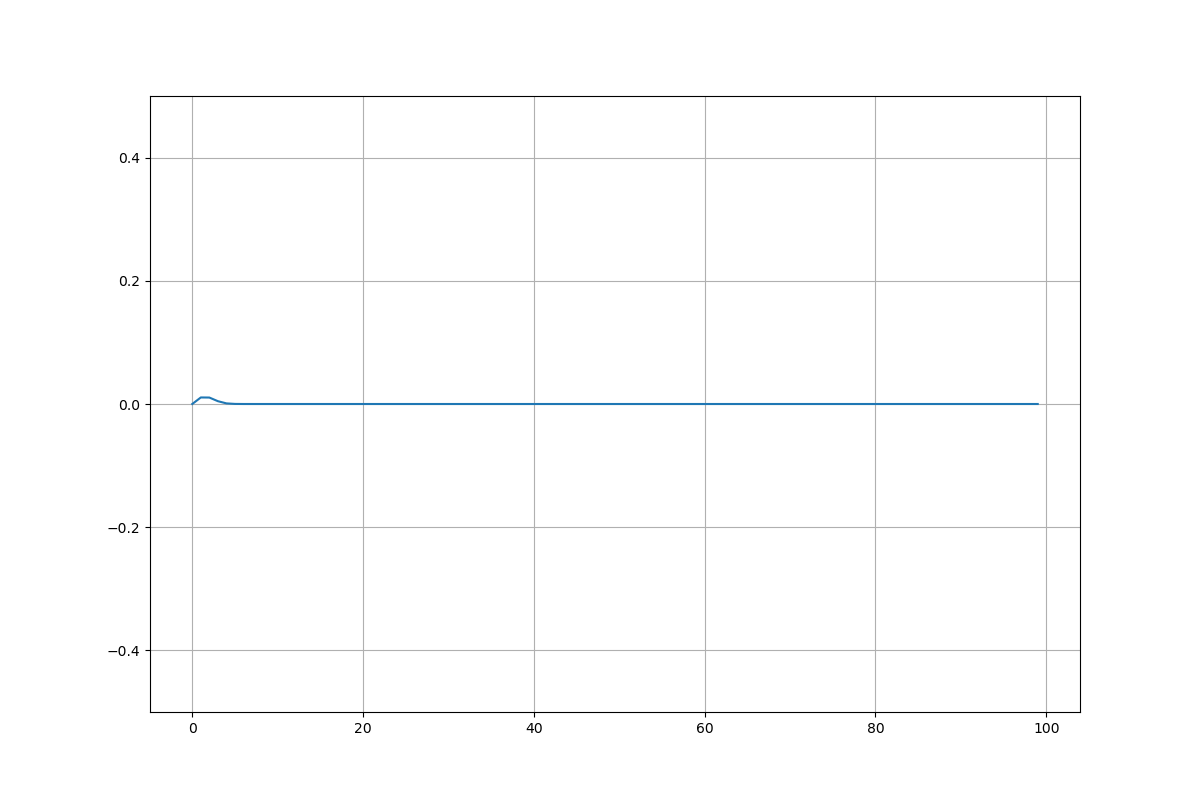

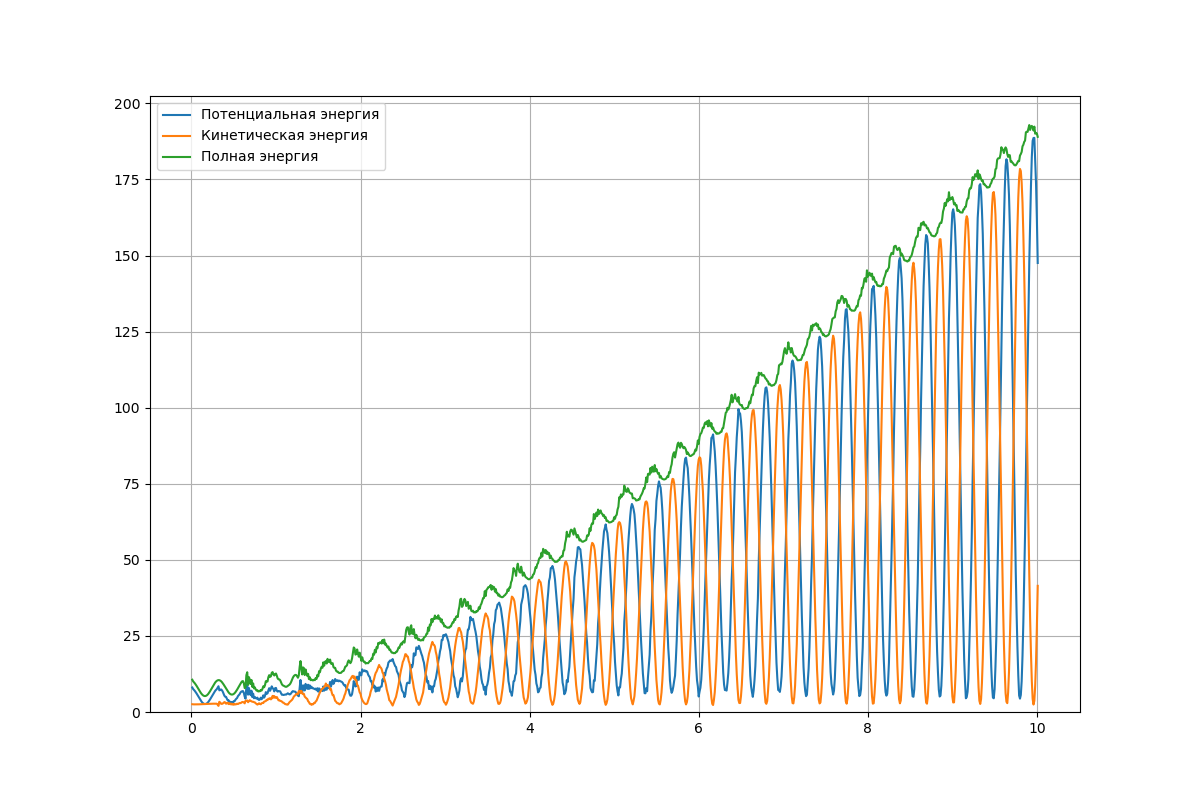

247.95363195286544 316.22776601683796


C:\Users\PJutch\AppData\Local\Temp\ipykernel_83848\168080776.py:36: RuntimeWarning: divide by zero encountered in divide
  c = np.sqrt(np.abs((d2x_dt2 / d2x_dpos2)))


In [26]:
%matplotlib widget

try:
    anim3.event_source.stop()
except Exception:
    pass

K_3 = 100000
SPRING_COUNT_3 = 100
anim3 = show_analysis(K_3, SPRING_COUNT_3, 0, 1000, 2 * np.sqrt(K_3) * np.sin(np.pi / 2 / (SPRING_COUNT_3 + 1)), 0, 10, 0.01, 1)